# Boston Housing Price Prediction using DNN
**Problem Statement:** Implement Boston housing price prediction problem by Linear regression using Deep Neural network.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import matplotlib.pyplot as plt

In [11]:
# Load the dataset and handle missing values
df = pd.read_csv("HousingData.csv")
df = df.dropna()
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [12]:
# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
model = Sequential()

model.add(Dense(10, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(1))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])


d:\BE\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 515.7208 - mae: 20.8644   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 495.9269 - mae: 20.4622 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 473.9381 - mae: 19.9897 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 449.3928 - mae: 19.4500 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 422.1706 - mae: 18.8145 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 392.1158 - mae: 18.0741 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 360.4340 - mae: 17.2433 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 328.7470 - mae: 16.3657 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 297.8304 - mae: 15.4336
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 268.1013 - mae: 14.4617 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 240.0198 - mae: 13.5073 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 214.9958 - ma

In [15]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 36.0014 - mae: 3.8139 
Test MSE: 36.0014
Test MAE: 3.8139


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


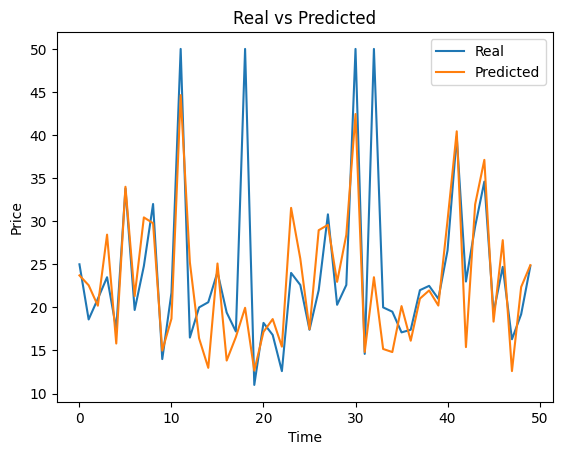

In [16]:
# Predict
pred = model.predict(X_test)

# Graph
plt.plot(y_test.values[:50], label="Real")
plt.plot(pred.flatten()[:50], label="Predicted")

plt.title("Real vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()